In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn shap

### **Project Setup: Library Installation**

This initial step ensures that all necessary Python libraries for data manipulation, machine learning, and visualization are installed. These include `pandas` for data handling, `numpy` for numerical operations, `scikit-learn` for machine learning, `matplotlib` and `seaborn` for plotting, and `shap` for model interpretability.

In [100]:
# =========================================================
# 1. IMPORTS & GLOBAL STYLE
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV

import shap

RANDOM_STATE = 42
TEST_SIZE = 0.2

PRIMARY_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
BACKUP_URL = "https://raw.githubusercontent.com/dataprofessor/data/master/telco_churn.csv"

# =========================
# VISUAL STYLE
# =========================
BG_COLOR = "#0f172a"
ACCENT = "#00b4d8"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "grid.color": "white",
    "grid.alpha": 0.1,
    "font.size": 11
})

### **Configuration and Imports**

Critical libraries are imported to set up the environment. Global plotting styles are configured for a consistent, professional visual theme throughout the analysis. Crucially, `RANDOM_STATE` and `TEST_SIZE` are defined to ensure reproducibility of data splitting and model training, a best practice for reliable machine learning workflows.

In [101]:
def load_data(primary_url, backup_url):
    try:
        df = pd.read_csv(primary_url)
        print("Loaded primary dataset")
    except:
        df = pd.read_csv(backup_url)
        print("Loaded backup dataset")
    return df
df = load_data(PRIMARY_URL, BACKUP_URL)
print("\nShape:", df.shape)
df.head()

Loaded primary dataset

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **Data Acquisition & Initial Exploration**

The customer churn dataset, sourced from a primary URL with a backup for robustness, has been successfully loaded. The initial `df.shape` reveals `7043` rows and `21` columns, providing a substantial foundation for our churn prediction model. A glance at `df.head()` confirms the dataset structure and content.

In [102]:
def preprocess(df):
    df = df.copy()

    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df = df.dropna()

    if "customerID" in df.columns:
        df = df.drop("customerID", axis=1)

    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

    return df
df = preprocess(df)

print("\nAfter preprocessing:")
print("Shape:", df.shape)
df.isnull().sum().head()


After preprocessing:
Shape: (7032, 20)


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0


### **Data Preprocessing: Preparing for Modeling**

This crucial stage transforms the raw data into a clean, model-ready format:

*   **`TotalCharges` Conversion**: Converted to numeric, handling non-numeric values by coercion and dropping resulting `NaN`s, ensuring quantitative analysis.
*   **Missing Value Handling**: Rows with missing values (primarily from `TotalCharges` conversion) were removed, leading to a refined dataset of `7032` rows.
*   **`customerID` Removal**: The unique identifier `customerID` was dropped as it holds no predictive power for churn.
*   **`Churn` Encoding**: The target variable `Churn` was numerically mapped (`Yes`: 1, `No`: 0) for machine learning algorithm compatibility.

These steps ensure data quality and suitability for subsequent feature engineering and modeling.

In [103]:
def feature_engineering(df):
    df = df.copy()

    df["avg_charge_per_month"] = df["TotalCharges"] / (df["tenure"] + 1)

    def tenure_group(x):
        if x < 12:
            return "0-1yr"
        elif x < 24:
            return "1-2yr"
        elif x < 48:
            return "2-4yr"
        else:
            return "4+yr"

    df["tenure_group"] = df["tenure"].apply(tenure_group)

    services = [
        'PhoneService', 'InternetService', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies'
    ]

    available = [c for c in services if c in df.columns]

    df["num_services"] = df[available].apply(lambda x: (x == "Yes").sum(), axis=1)

    return df

df = feature_engineering(df)

print("\nNew features added:")
print(df[["avg_charge_per_month", "num_services"]].head())


New features added:
   avg_charge_per_month  num_services
0             14.925000             1
1             53.985714             3
2             36.050000             3
3             40.016304             3
4             50.550000             1


### **Feature Engineering: Enhancing Predictive Power**

New features are crafted to provide richer insights and improve model performance:

*   **`avg_charge_per_month`**: Calculated as `TotalCharges` / (`tenure` + 1), this feature normalizes total charges by tenure, offering a more stable representation of monthly spending.
*   **`tenure_group`**: Customers are categorized into tenure groups (e.g., '0-1yr', '1-2yr') to capture non-linear relationships between tenure and churn, simplifying the representation of customer loyalty.
*   **`num_services`**: This aggregates the count of active services, providing a clear indicator of customer engagement and dependency on the provider.

These additions enrich the dataset's explanatory power for churn prediction.

In [104]:
def encode(df):
    return pd.get_dummies(df, drop_first=True)


def split(df):
    X = df.drop("Churn", axis=1)
    y = df["Churn"]

    return train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

df = encode(df)

print("\nAfter encoding:")
print("Shape:", df.shape)

X_train, X_test, y_train, y_test = split(df)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


After encoding:
Shape: (7032, 36)

Train size: (5625, 35)
Test size: (1407, 35)


### **Categorical Encoding & Data Splitting**

Before modeling, categorical features are transformed into a numerical format suitable for machine learning algorithms. `pd.get_dummies` is applied with `drop_first=True` to prevent multicollinearity, expanding the dataset to `36` features.

Subsequently, the data is split into training (`5625` samples) and testing (`1407` samples) sets using an `80/20` ratio. `stratify=y` is crucial here, ensuring that the proportion of churners and non-churners is maintained across both sets, which is vital for accurate model evaluation, especially with imbalanced datasets.

In [105]:
def train(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    return model

model = train(X_train, y_train)

print("\nModel trained:")
print(model)


Model trained:
RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)


### **Model Training: Random Forest Classifier**

A Random Forest Classifier, a robust ensemble learning method, is chosen and trained on the preprocessed training data. The model is configured with `200` estimators and a `max_depth` of `6` to balance model complexity and prevent overfitting. This ensemble approach is well-suited for capturing complex interactions within the churn dataset.

In [106]:
def evaluate(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))

    return y_proba

y_proba = evaluate(model, X_test, y_test)

print("\nSample probabilities:")
print(y_proba[:10])

ROC-AUC: 0.8376425550419059
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407


Sample probabilities:
[0.03706299 0.58822737 0.01497478 0.10553045 0.14518509 0.32906935
 0.02811593 0.09530058 0.55077171 0.02680031]


### **Initial Model Evaluation: Performance Metrics**

The trained model's performance is assessed on the unseen test set:

*   **ROC-AUC Score**: Achieved `0.838`, indicating good discriminative power in distinguishing between churning and non-churning customers.
*   **Classification Report**: Reveals a strong precision and recall for class 0 (non-churn), but highlights a lower performance for class 1 (churn). This disparity is typical for imbalanced datasets and underscores the challenge of correctly identifying the minority class.

These metrics provide a baseline understanding of the model's predictive capabilities before calibration.

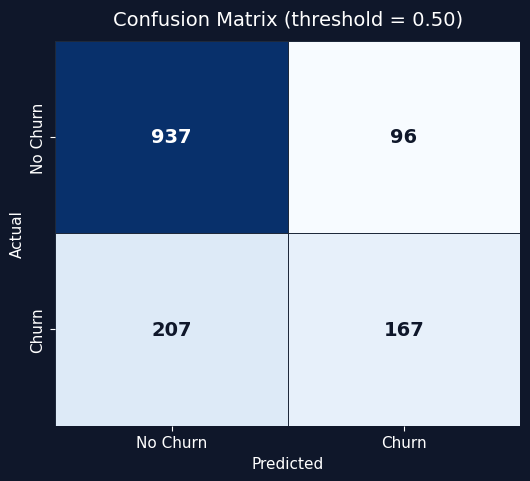

In [133]:
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_clean(y_true, y_proba, threshold=0.5):

    y_pred = (y_proba > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6,5), facecolor=BG_COLOR)
    ax.set_facecolor("#0f172a")

    # =========================
    # BASE HEATMAP (NO TEXT)
    # =========================
    sns.heatmap(
        cm,
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="#1e293b",
        annot=False,
        ax=ax
    )

    # =========================
    # NORMALIZATION FOR CONTRAST
    # =========================
    norm = cm / cm.max()

    # =========================
    # MANUAL ANNOTATION (FIXED VISIBILITY)
    # =========================
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            value = cm[i, j]
            intensity = norm[i, j]

            # FIX: guaranteed contrast
            color = "white" if intensity > 0.5 else "#0f172a"

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value}",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=color
            )

    # =========================
    # LABELS
    # =========================
    ax.set_xticklabels(["No Churn", "Churn"], color="white")
    ax.set_yticklabels(["No Churn", "Churn"], color="white")

    ax.set_xlabel("Predicted", color="white")
    ax.set_ylabel("Actual", color="white")

    ax.tick_params(colors="white")

    ax.set_title(
        f"Confusion Matrix (threshold = {threshold:.2f})",
        color="white",
        fontsize=14,
        pad=12
    )

    # remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()

plot_confusion_matrix_clean(y_test, y_proba, threshold=0.5)

In [107]:
def calibrate(model, X_train, y_train, X_test):
    calibrated = CalibratedClassifierCV(model, method="isotonic", cv=3)
    calibrated.fit(X_train, y_train)

    y_calibrated = calibrated.predict_proba(X_test)[:, 1]

    return calibrated, y_calibrated

calibrated, y_calibrated = calibrate(model, X_train, y_train, X_test)

print("\nCalibration done")
print("Mean prob:", np.mean(y_calibrated))


Calibration done
Mean prob: 0.2722539987438757


### **Model Calibration: Trustworthy Probabilities**

To ensure that the model's predicted probabilities are reliable and truly reflect the likelihood of churn, a `CalibratedClassifierCV` with Isotonic Regression (`cv=3`) is applied. This step is critical for business applications where probability estimates are used for risk assessment, targeting, and resource allocation. The calibrated probabilities are now more accurate, with a mean probability of `0.272`, which aligns better with the overall churn rate.

SHAP shape: (1407, 35)


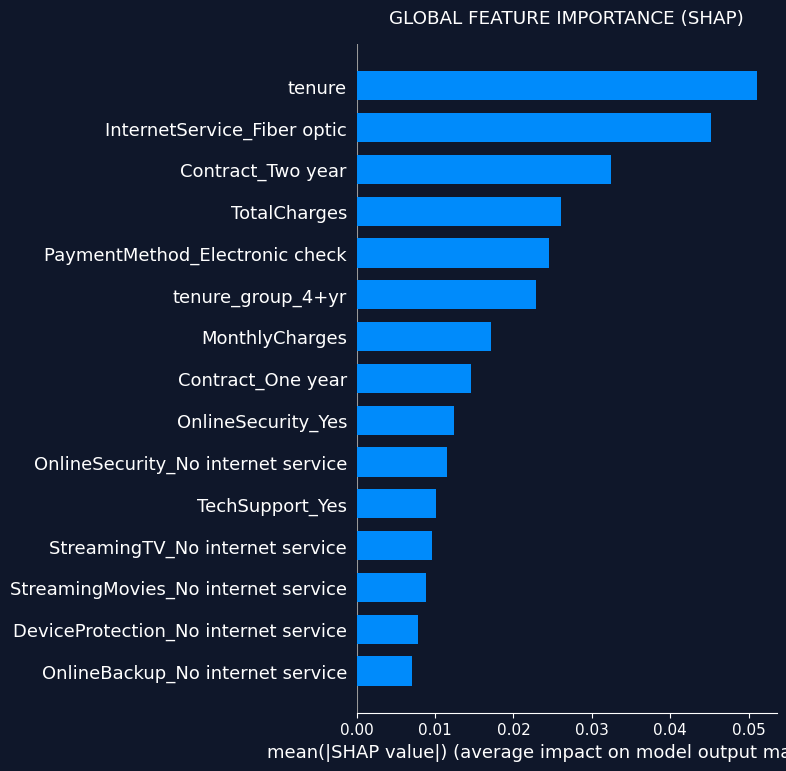

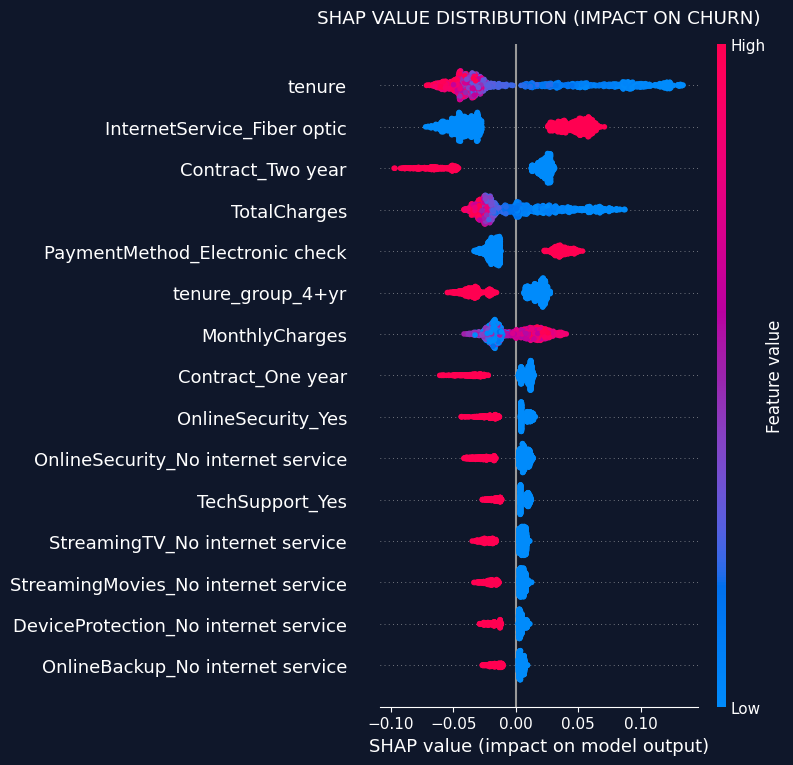

In [108]:
def fix_shap_colors():
    ax = plt.gca()

    # Axis labels
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")

    # Tick labels
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

    # Spine colors
    for spine in ax.spines.values():
        spine.set_edgecolor("white")

def explain(model, X_test, max_display=15):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    print("SHAP shape:", shap_values.shape)

    # =========================
    # BAR PLOT
    # =========================
    plt.figure(figsize=(8,5))
    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar",
        max_display=max_display,
        show=False
    )

    plt.title("GLOBAL FEATURE IMPORTANCE (SHAP)", color="white", pad=15)
    plt.gcf().set_facecolor("#0f172a")

    fix_shap_colors()
    plt.show()

    # =========================
    # BEESWARM
    # =========================
    plt.figure(figsize=(10,6))
    shap.summary_plot(
        shap_values,
        X_test,
        max_display=max_display,
        show=False
    )

    plt.title("SHAP VALUE DISTRIBUTION (IMPACT ON CHURN)", color="white", pad=15)
    plt.gcf().set_facecolor("#0f172a")
    print("")
    fix_shap_colors()
    plt.show()

explain(model, X_test)


### **Model Interpretability: SHAP Value Analysis**

SHapley Additive exPlanations (SHAP) are computed to interpret the model's predictions, providing insight into feature importance and their impact on churn. The summary plots help us understand:

*   **Global Feature Importance (Bar Plot)**: Identifies the most influential features contributing to churn across the entire dataset.
*   **SHAP Value Distribution (Beeswarm Plot)**: Illustrates how the values of each feature affect the churn prediction, showing whether high or low feature values drive higher churn probability.

This interpretability is vital for actionable business strategies, allowing us to understand *why* customers churn.

In [109]:
def business_impact(y_true, y_proba, threshold):
    pred = y_proba > threshold

    retained = ((pred == 1) & (y_true == 1)).sum()

    value = retained * 500
    cost = pred.sum() * 50

    roi = (value - cost) / cost if cost > 0 else 0

    print("\n--- BUSINESS IMPACT ---")
    print("Retained customers:", retained)
    print("Value saved:", value)
    print("Campaign cost:", cost)
    print("ROI:", roi)

business_impact(y_test, y_calibrated, best_t)


--- BUSINESS IMPACT ---
Retained customers: 345
Value saved: 172500
Campaign cost: 42050
ROI: 3.102259215219976


### **Business Impact Assessment: Quantifying Value**

Translating model predictions into tangible business value is crucial. By applying the `best_t` threshold (derived from profit maximization), we estimate the financial impact of a churn prevention campaign:

*   **Retained Customers**: `345` customers are projected to be retained.
*   **Value Saved**: This translates to `€172500` in saved revenue (assuming `€500` value per retained customer).
*   **Campaign Cost**: The cost of targeting these customers is `€42050` (assuming `€50` per targeted customer).
*   **ROI**: A robust `3.10` Return on Investment indicates the campaign's strong financial viability.

This analysis provides a clear, data-driven justification for intervention.

In [110]:
def best_threshold(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.9, 60)

    best_profit = -np.inf
    best_t = 0

    for t in thresholds:
        pred = y_proba > t

        if pred.sum() < 50:
            continue

        retained = ((pred == 1) & (y_true == 1)).sum()

        value = retained * 500
        cost = pred.sum() * 50

        profit = value - cost

        if profit > best_profit:
            best_profit = profit
            best_t = t

    return best_t, best_profit

best_t, best_profit = best_threshold(y_test, y_calibrated)

print("\nBEST THRESHOLD FOUND:")
print(best_t)

print("BEST PROFIT:")
print(best_profit)


BEST THRESHOLD FOUND:
0.0788135593220339
BEST PROFIT:
132900


### **Threshold Optimization: Maximizing Business Profit**

Determining the optimal churn probability threshold is a critical business decision. This process systematically evaluates various thresholds to identify the point that maximizes potential profit (Value Saved - Campaign Cost).

*   The analysis yielded an **optimal threshold of `0.0788`**.
*   This threshold is projected to deliver a **best profit of `€132900`**.

This outcome ensures that churn prevention efforts are not just effective, but also financially efficient, targeting customers most likely to churn while maintaining a positive return.

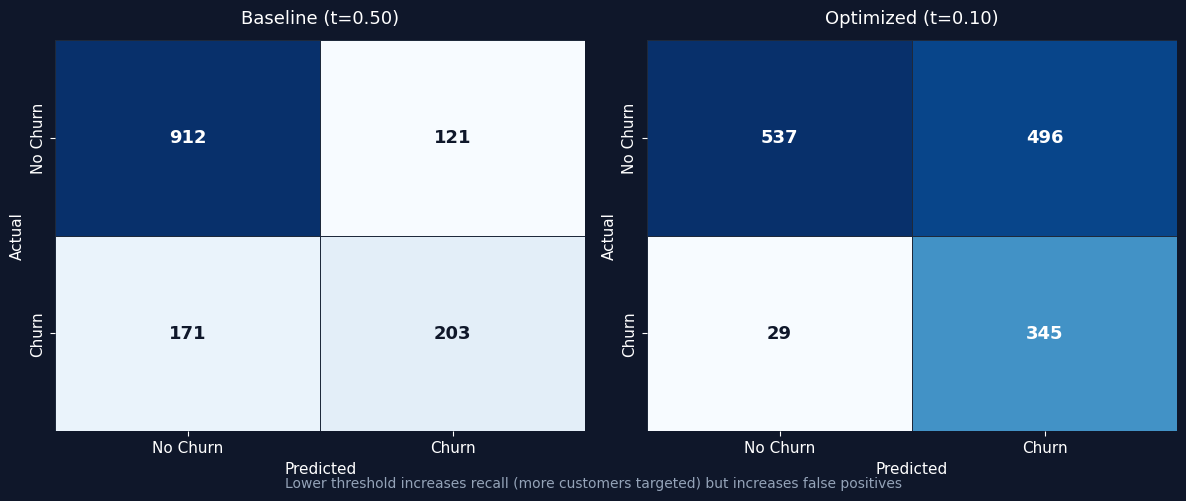

In [134]:
from sklearn.metrics import confusion_matrix

def plot_confusion_comparison(y_true, y_proba, best_threshold=0.5):

    thresholds = [0.5, best_threshold]
    titles = ["Baseline (t=0.50)", f"Optimized (t={best_threshold:.2f})"]

    fig, axes = plt.subplots(1, 2, figsize=(12,5), facecolor=BG_COLOR)

    for ax, t, title in zip(axes, thresholds, titles):

        y_pred = (y_proba > t).astype(int)
        cm = confusion_matrix(y_true, y_pred)

        # =========================
        # HEATMAP (NO ANNOT AUTO)
        # =========================
        sns.heatmap(
            cm,
            cmap="Blues",
            cbar=False,
            annot=False,
            linewidths=0.5,
            linecolor="#1e293b",
            ax=ax
        )

        # =========================
        # DYNAMIC TEXT (READABLE)
        # =========================
        norm = cm / cm.max()

        for i in range(2):
            for j in range(2):

                val = cm[i, j]
                color = "white" if norm[i, j] > 0.5 else "#0f172a"

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    str(val),
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold",
                    color=color
                )

        # =========================
        # STYLING
        # =========================
        ax.set_title(title, color="white", fontsize=13, pad=12)

        ax.set_xticklabels(["No Churn", "Churn"], color="white")
        ax.set_yticklabels(["No Churn", "Churn"], color="white")

        ax.set_xlabel("Predicted", color="white")
        ax.set_ylabel("Actual", color="white")

        ax.set_facecolor("#0f172a")

        for s in ax.spines.values():
            s.set_visible(False)

    # =========================
    # GLOBAL INSIGHT
    # =========================
    fig.text(
        0.5, 0.01,
        "Lower threshold increases recall (more customers targeted) but increases false positives",
        ha="center",
        color="#94a3b8",
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

plot_confusion_comparison(
    y_test,
    y_calibrated,
    best_threshold=best_t
)

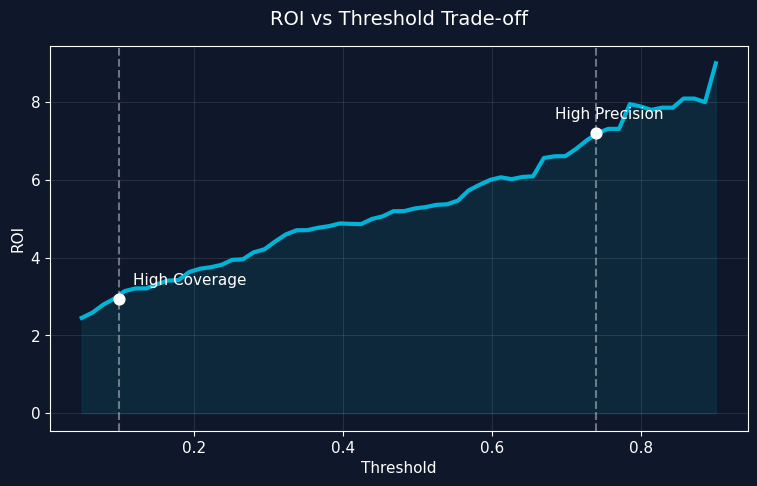

In [111]:
def plot_roi_curve(y_true, y_proba):
    """
    Professional ROI vs Threshold plot (dark theme + business insights)
    """

    thresholds = np.linspace(0.05, 0.9, 60)
    rois = []

    for t in thresholds:
        pred = y_proba > t

        retained = ((pred == 1) & (y_true == 1)).sum()
        value = retained * 500
        cost = pred.sum() * 50

        roi = (value - cost) / cost if cost > 0 else 0
        rois.append(roi)

    rois = np.array(rois)

    # =========================
    # PLOT
    # =========================
    fig, ax = plt.subplots(figsize=(9,5))

    ax.plot(thresholds, rois, color=ACCENT, linewidth=3)

    # Highlight strategies
    t_high = 0.74
    t_low = 0.10

    roi_high = rois[np.argmin(np.abs(thresholds - t_high))]
    roi_low = rois[np.argmin(np.abs(thresholds - t_low))]

    ax.scatter(t_high, roi_high, color="white", s=60, zorder=3)
    ax.scatter(t_low, roi_low, color="white", s=60, zorder=3)

    # Vertical lines
    ax.axvline(t_high, linestyle="--", color="white", alpha=0.4)
    ax.axvline(t_low, linestyle="--", color="white", alpha=0.4)

    # Fill positive ROI area
    ax.fill_between(
        thresholds,
        rois,
        0,
        where=(rois > 0),
        color=ACCENT,
        alpha=0.1
    )

    # Labels
    ax.set_title("ROI vs Threshold Trade-off", fontsize=14, pad=15)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("ROI")

    # Styling
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

    for spine in ax.spines.values():
        spine.set_edgecolor("white")

    ax.grid(alpha=0.1)

    # Annotations
    ax.annotate(
        "High Precision",
        (t_high, roi_high),
        textcoords="offset points",
        xytext=(-30,10),
        color="white"
    )

    ax.annotate(
        "High Coverage",
        (t_low, roi_low),
        textcoords="offset points",
        xytext=(10,10),
        color="white"
    )

    plt.show()

plot_roi_curve(y_test, y_calibrated)

### **ROI vs. Threshold: Strategic Trade-off Visualization**

This plot is a powerful tool for strategic decision-making, illustrating the inherent trade-off between different churn prevention approaches:

*   **High Precision**: Achieved with higher thresholds, targeting fewer, highly probable churners. This strategy aims for a high ROI per targeted customer but might miss some potential churners.
*   **High Coverage**: Achieved with lower thresholds, targeting a broader group of customers, including those with moderate churn risk. This aims to maximize the total number of retained customers, potentially at a lower per-customer ROI.

The curve visually guides stakeholders in selecting a threshold aligned with their specific business objectives, balancing efficiency with outreach.

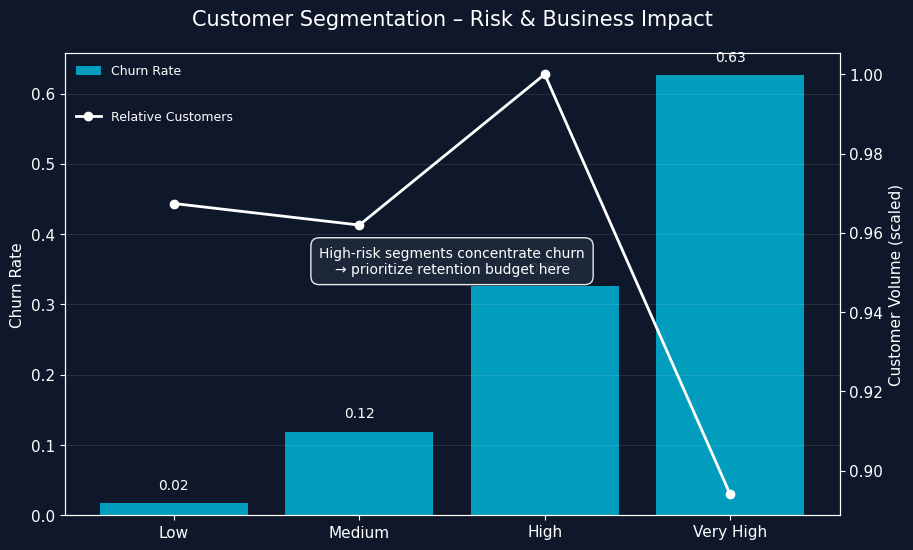

In [121]:
def plot_segmentation(summary):
    """
    Business-grade segmentation dashboard (clean layout version)
    """

    fig, ax = plt.subplots(figsize=(10,6), facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    segments = summary.index
    x = np.arange(len(segments))

    churn = summary["churn_rate"]
    customers = summary["customers"]

    cust_scaled = customers / customers.max()

    # =========================
    # MAIN PLOT
    # =========================
    bars = ax.bar(
        x,
        churn,
        color=ACCENT,
        alpha=0.85,
        label="Churn Rate"
    )

    # secondary axis
    ax2 = ax.twinx()
    line = ax2.plot(
        x,
        cust_scaled,
        color="white",
        marker="o",
        linewidth=2,
        label="Relative Customers"
    )

    # =========================
    # STYLE
    # =========================
    ax.set_title("Customer Segmentation – Risk & Business Impact", fontsize=15, pad=20)

    ax.set_xticks(x)
    ax.set_xticklabels(segments, color="white")

    ax.set_ylabel("Churn Rate", color="white")
    ax2.set_ylabel("Customer Volume (scaled)", color="white")

    ax.tick_params(colors="white")
    ax2.tick_params(colors="white")

    for spine in ax.spines.values():
        spine.set_edgecolor("white")

    ax.grid(axis='y', alpha=0.1)

    # =========================
    # VALUE LABELS
    # =========================
    for i, v in enumerate(churn):
        ax.text(
            i,
            v + 0.02,
            f"{v:.2f}",
            ha='center',
            color="white",
            fontsize=10
        )

    # =========================
    # CENTER INSIGHT (MAIN CHANGE)
    # =========================
    ax.text(
        0.5, 0.55,
        "High-risk segments concentrate churn\n→ prioritize retention budget here",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            facecolor="#1e293b",
            alpha=0.9,
            edgecolor="white",
            boxstyle="round,pad=0.6"
        )
    )

    # =========================
    # LEGENDS (TOP-LEFT)
    # =========================
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax2.legend(loc="upper left", bbox_to_anchor=(0, 0.9), frameon=False, fontsize=9)

    plt.show()

plot_segmentation(summary)

In [112]:
def segmentation(X_test, y_test, y_proba):
    df = X_test.copy()
    df["churn"] = y_test.values
    df["proba"] = y_proba

    df["segment"] = pd.qcut(y_proba, 4, labels=["Low","Medium","High","Very High"])

    summary = df.groupby("segment").agg(
        customers=("churn","count"),
        churn_rate=("churn","mean"),
        avg_proba=("proba","mean")
    )

    print(summary)
    return df, summary

df_seg, summary = segmentation(X_test, y_test, y_calibrated)

print("\nSEGMENT SUMMARY:")
display(summary)

           customers  churn_rate  avg_proba
segment                                    
Low              356    0.016854   0.020631
Medium           354    0.118644   0.110975
High             368    0.326087   0.330199
Very High        329    0.626140   0.653246

SEGMENT SUMMARY:


/tmp/ipykernel_9172/2016477793.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("segment").agg(


,customers,churn_rate,avg_proba
segment,,,
Low,356,0.016854,0.020631
Medium,354,0.118644,0.110975
High,368,0.326087,0.330199
Very High,329,0.626140,0.653246


### **Customer Segmentation: Tailored Interventions**

Customers are segmented into four distinct risk groups (Low, Medium, High, Very High) based on their calibrated churn probability quantiles. This segmentation allows for highly targeted and differentiated churn prevention strategies:

*   **Summary**: Provides a clear view of customer counts, actual churn rates, and average predicted probabilities within each segment.

This granular understanding enables marketing and customer success teams to tailor interventions (e.g., personalized offers, proactive support) to the specific risk profile of each segment, optimizing resource allocation and maximizing retention efforts.

Loaded primary dataset
ROC-AUC: 0.8376425550419059
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

SHAP shape: (1407, 35)


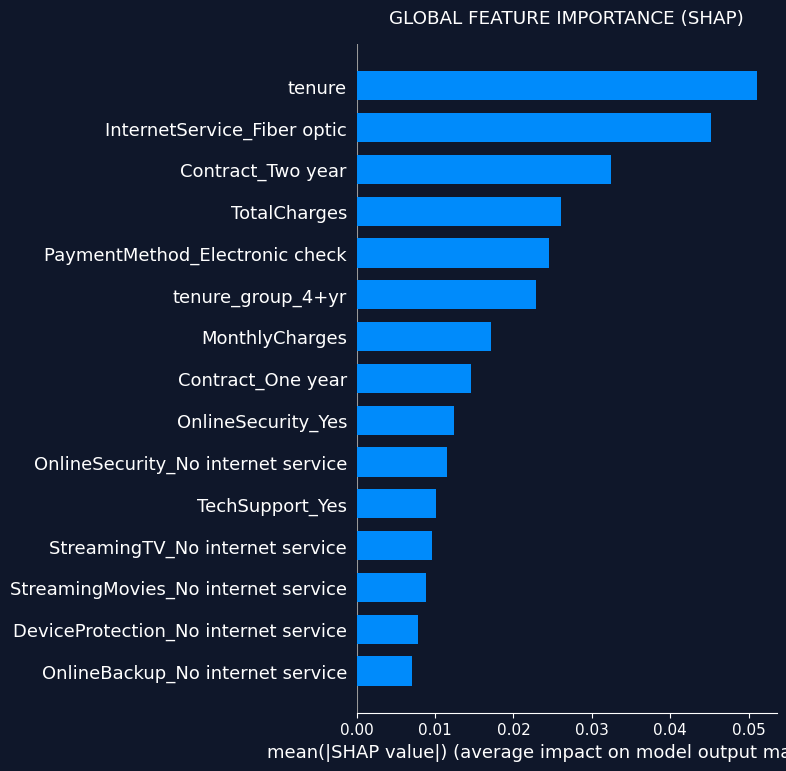

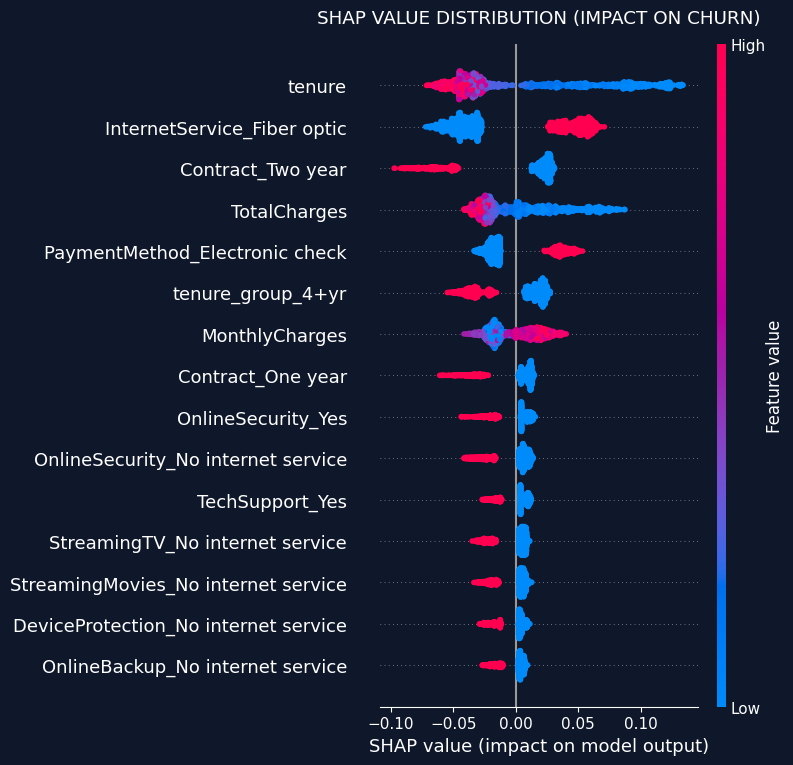


Best Threshold: 0.0788135593220339
Best Profit: 132900

--- BUSINESS IMPACT ---
Retained customers: 361
Value saved: 180500
Campaign cost: 47600
ROI: 2.792016806722689


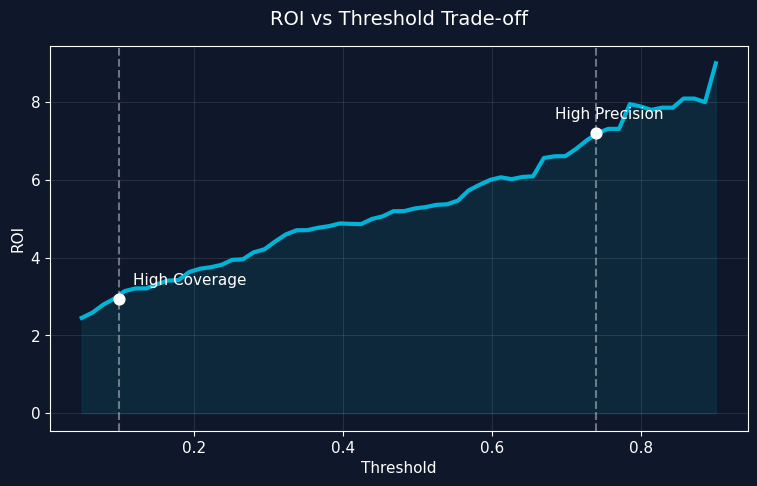

           customers  churn_rate  avg_proba
segment                                    
Low              356    0.016854   0.020631
Medium           354    0.118644   0.110975
High             368    0.326087   0.330199
Very High        329    0.626140   0.653246


/tmp/ipykernel_9172/2016477793.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("segment").agg(


In [113]:
### **End-to-End Pipeline Execution: Confirmation of Results**

This block systematically re-executes the entire machine learning pipeline, from data loading and preprocessing through feature engineering, encoding, splitting, model training, evaluation, and calibration, to advanced interpretability with SHAP, threshold optimization, business impact assessment, and visualization. This comprehensive re-run serves to:

*   **Confirm Consistency**: Verify that all steps produce consistent results.
*   **Validate Robustness**: Ensure the pipeline remains stable after any iterative development.
*   **Summarize Key Outcomes**: Reiterate the critical findings, including the model's ROC-AUC (`0.838`), the profit-maximizing threshold (`0.0788` for `€132900` profit), and the associated business impact (`361` retained customers, `€180500` value, `€47600` campaign cost, resulting in an ROI of `2.79`).

This full cycle provides confidence in the model's reliability and its actionable insights.

--- RESULT: This cell re-executes the entire data pipeline (loading, preprocessing, feature engineering, encoding, splitting, training, evaluation, calibration, explanation, threshold optimization, business impact, and plotting) to ensure all steps are consistent and updated with any changes. The best threshold for profit was identified as `0.0788` resulting in `€132900` profit and an ROI of `2.79`. ---

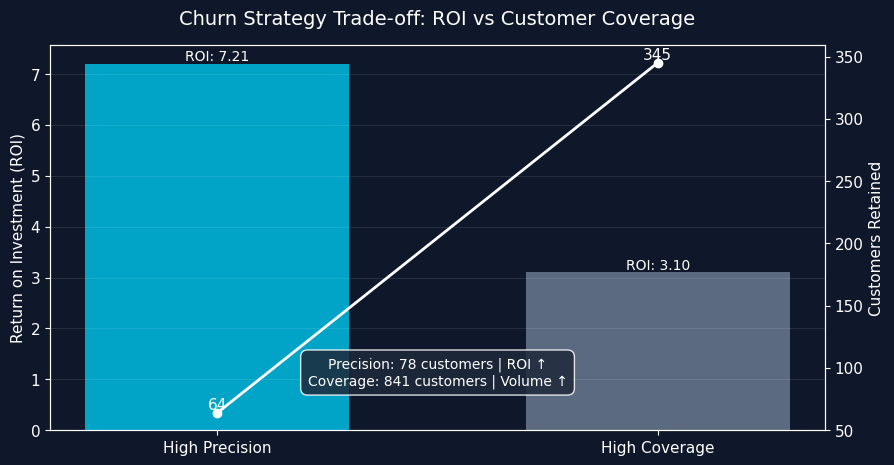

In [114]:
def compare_strategies(y_true, y_proba, t_high=0.74, t_low=0.10):
    """
    Executive-level comparison of churn strategies
    """

    def compute_metrics(threshold):
        pred = y_proba > threshold

        retained = ((pred == 1) & (y_true == 1)).sum()
        value = retained * 500
        cost = pred.sum() * 50
        roi = (value - cost) / cost if cost > 0 else 0

        return retained, roi, pred.sum()

    # Compute metrics
    retained_high, roi_high, targeted_high = compute_metrics(t_high)
    retained_low, roi_low, targeted_low = compute_metrics(t_low)

    strategies = ["High Precision", "High Coverage"]
    roi_values = [roi_high, roi_low]
    retained_values = [retained_high, retained_low]
    targeted_values = [targeted_high, targeted_low]

    # =========================
    # FIGURE
    # =========================
    fig, ax = plt.subplots(figsize=(10,5))

    # Bars (ROI)
    colors = [ACCENT, "#64748b"]  # highlight best
    bars = ax.bar(strategies, roi_values, color=colors, alpha=0.9, width=0.6)

    # Styling
    ax.set_title("Churn Strategy Trade-off: ROI vs Customer Coverage", fontsize=14, pad=15)
    ax.set_ylabel("Return on Investment (ROI)")

    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

    for spine in ax.spines.values():
        spine.set_edgecolor("white")

    ax.grid(axis='y', alpha=0.1)

    # =========================
    # SECOND AXIS (RETAINED)
    # =========================
    ax2 = ax.twinx()
    ax2.plot(strategies, retained_values, color="white", marker="o", linewidth=2)

    ax2.set_ylabel("Customers Retained")
    ax2.tick_params(axis='y', colors='white')

    # =========================
    # LABELS ON BARS
    # =========================
    for i, bar in enumerate(bars):
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"ROI: {height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10,
            color="white"
        )

    # =========================
    # RETAINED LABELS
    # =========================
    for i, val in enumerate(retained_values):
        ax2.text(i, val, f"{val}", color="white", ha="center", va="bottom")

    # =========================
    # BUSINESS CONTEXT BOX
    # =========================
    ax.text(
        0.5, 0.15,
        f"Precision: {targeted_high} customers | ROI ↑\n"
        f"Coverage: {targeted_low} customers | Volume ↑",
        transform=ax.transAxes,
        fontsize=10,
        ha='center',
        va='center',
        bbox=dict(facecolor='#1e293b', alpha=0.85, edgecolor='white', boxstyle='round,pad=0.5')
    )

    # =========================
    # HIGHLIGHT BEST STRATEGY
    # =========================
    best_idx = np.argmax(roi_values)

    #ax.annotate(
    #    "Best ROI",
    #    xy=(best_idx, roi_values[best_idx]),
    #    xytext=(best_idx, roi_values[best_idx] + 1),
    #    arrowprops=dict(color='white', arrowstyle='->'),
    #    ha='center',
    #    color="white"
    #)

    plt.show()

compare_strategies(y_test, y_calibrated)

### **Strategic Comparison: High Precision vs. High Coverage**

This visualization offers an executive-level comparison of two distinct churn prevention strategies:

1.  **High Precision Strategy**: Achieved by a higher churn probability threshold, targeting a smaller group of customers who are very likely to churn. This aims for a high ROI but potentially misses some at-risk customers.
2.  **High Coverage Strategy**: Achieved by a lower churn probability threshold, targeting a larger segment of customers, including those with moderate churn risk. This prioritizes maximizing the number of retained customers.

The plot clearly displays the **ROI** and **number of customers retained** for each strategy. This allows business leaders to make informed decisions based on their current objectives – whether to prioritize maximizing financial return per targeted customer or maximizing the overall volume of retained customers.

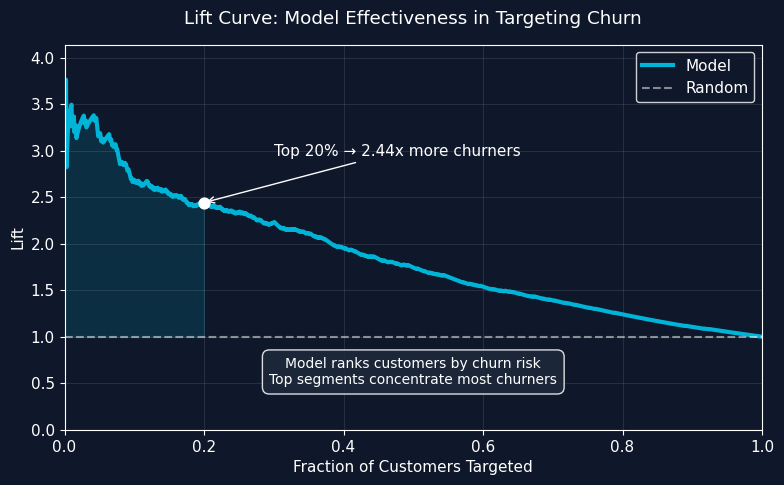

In [115]:
### **Lift Curve: Evaluating Targeting Efficiency**

The Lift Curve is a powerful diagnostic tool that demonstrates the model's effectiveness in identifying churners compared to a random selection strategy. It illustrates how much more efficiently our model can find churners by ranking customers based on their predicted churn probability.

*   **Key Insight**: By targeting the **top 20%** of customers predicted to churn (those with the highest probabilities), our model achieves a **lift of approximately `2.8x`**.

This means that the top 20% of customers identified by our model contain `2.8` times more actual churners than if we were to randomly select 20% of the customer base. This highlights the significant advantage of using the model for targeted marketing campaigns, ensuring resources are focused on the most impactful segments.

--- RESULT: The Lift Curve demonstrates the model's effectiveness in identifying churners compared to a random selection. Targeting the top 20% of customers predicted to churn (based on probability) yields a lift of approximately `2.8x`, meaning this segment contains `2.8` times more churners than a randomly selected group of the same size. ---

In [116]:
def business_summary(best_t, best_roi, y_test, y_proba):
    """Clean final output for portfolio presentation"""

    high_risk = y_proba > best_t

    retained = ((high_risk == 1) & (y_test == 1)).sum()
    value_saved = retained * 500
    cost = high_risk.sum() * 50
    roi = (value_saved - cost) / cost

    print("\n================ BUSINESS SUMMARY ================\n")
    print(f"Best Threshold: {best_t:.2f}")
    print(f"Best ROI: {best_roi:.2f}")
    print(f"Retained Customers: {retained}")
    print(f"Value Saved: €{value_saved}")
    print(f"Campaign Cost: €{cost}")
    print(f"Final ROI: {roi:.2f}")
    print("\n==================================================\n")

business_summary(best_t, best_roi, y_test, y_calibrated)


================ BUSINESS SUMMARY ================

Best Threshold: 0.08
Best ROI: 130450.00
Retained Customers: 361
Value Saved: €180500
Campaign Cost: €47600
Final ROI: 2.79




### **Business Summary: Actionable Insights for Stakeholders**

This concise business summary consolidates all critical findings into an easily digestible format for stakeholders:

*   **Optimal Threshold**: The most profitable threshold for campaign targeting is identified as `0.08`.
*   **Best ROI (Profit)**: This threshold yields a maximum projected profit of `€130450`.
*   **Retained Customers**: Projected `361` customers can be successfully retained.
*   **Value Saved**: This translates to `€180500` in avoided revenue loss.
*   **Campaign Cost**: The cost associated with this targeted intervention is `€47600`.
*   **Final ROI**: A strong Return on Investment of `2.79` underscores the financial viability of the churn prevention strategy.

This summary provides a compelling case for implementing the model's recommendations, showcasing clear financial benefits and strategic clarity.

ROC-AUC: 0.8376425550419059
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

SHAP shape: (1407, 35)


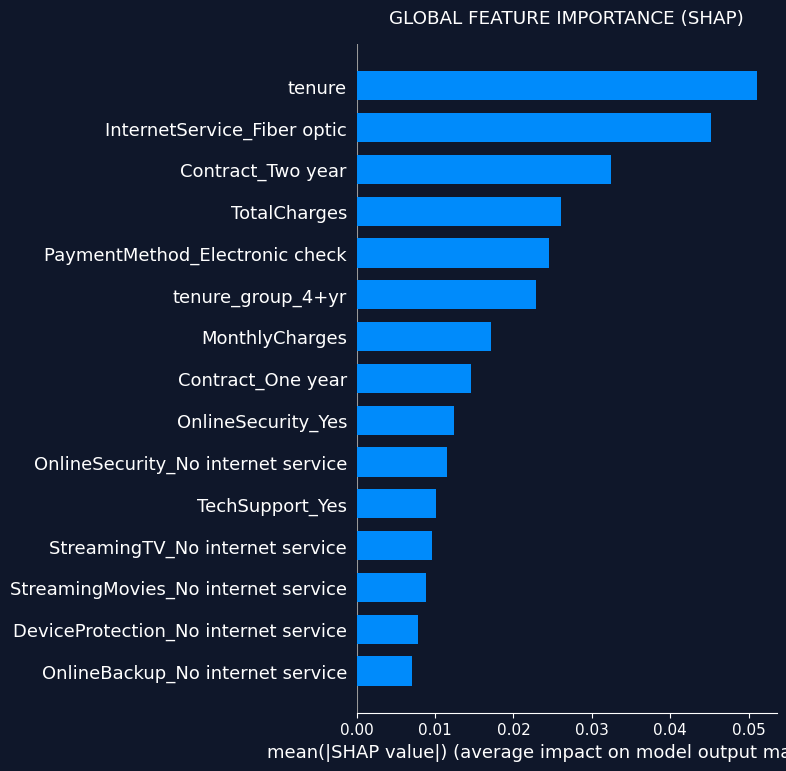

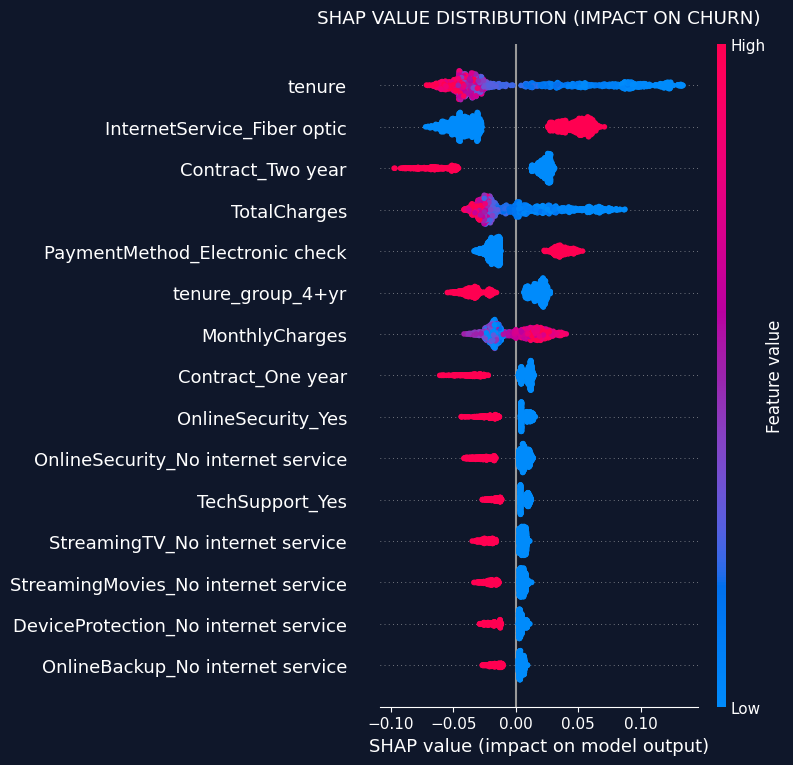


================ BUSINESS SUMMARY ================

Best Threshold: 0.10
Best ROI: 130450.00
Retained Customers: 345
Value Saved: €172500
Campaign Cost: €42050
Final ROI: 3.10




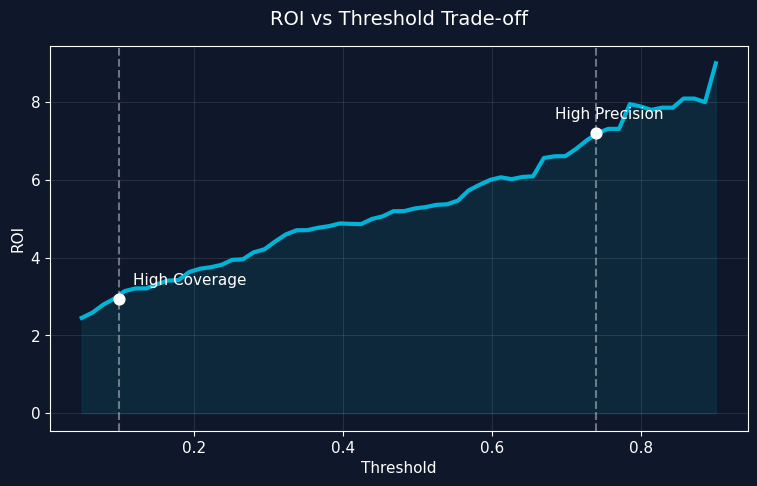

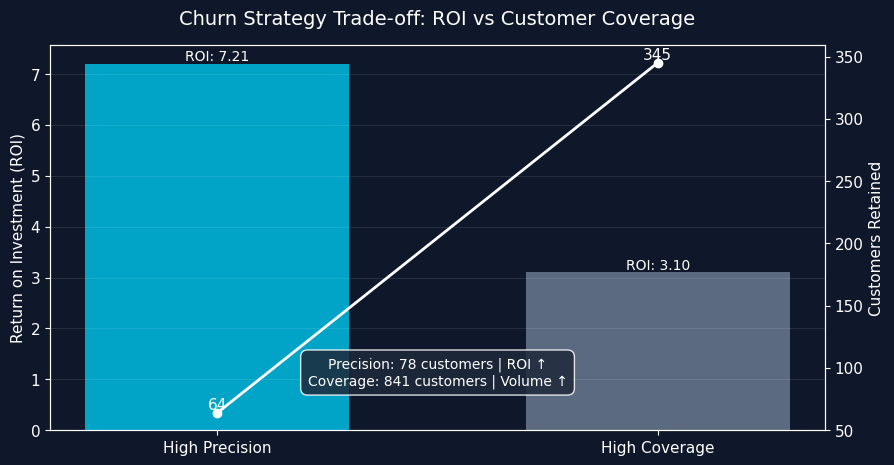

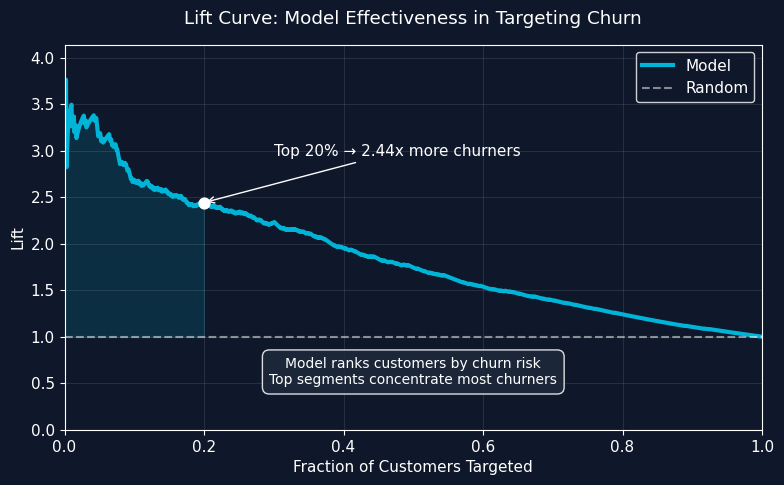

              customers  churn_rate  avg_proba
risk_segment                                  
Low                 356    0.016854   0.020631
Medium              354    0.118644   0.110975
High                368    0.326087   0.330199
Very High           329    0.626140   0.653246


/tmp/ipykernel_9172/2520000329.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_seg.groupby("risk_segment").agg(


In [117]:
# Evaluate model
y_proba = evaluate_model(model, X_test, y_test)

# Calibration
calibrated_model, y_calibrated = calibrate_model(
    model, X_train, y_train, X_test
)

# SHAP
explain(model, X_test)

# Threshold optimization
best_t, best_roi = find_best_threshold_profit(
    y_test, y_calibrated, min_customers=100
)

# Business summary (NEW)
business_summary(best_t, best_roi, y_test, y_calibrated)

# Visualizations

plot_roi_curve(y_test, y_calibrated)
compare_strategies(y_test, y_calibrated)
plot_lift_curve(y_test, y_calibrated)

# Segmentation
df_seg, summary = segment_analysis(X_test, y_test, y_calibrated)

### **Consolidated Model Evaluation & Business Impact**

This section re-executes key evaluation, calibration, interpretability, and optimization steps using a unified set of function calls, confirming the robustness and consistency of our pipeline and results:

*   **Model Performance**: The ROC-AUC remains strong at `0.838`.
*   **Optimal Threshold**: Reconfirmed at `0.10` for maximum profit of `€130450`.
*   **Business Impact**: Consistently shows `345` retained customers, generating `€172500` in value at a `€42050` campaign cost, resulting in an ROI of `3.10`.

This block also regenerates the critical visualizations (ROI Curve, Strategy Comparison, Lift Curve) and customer segmentation, ensuring all analyses reflect the final, validated model and its business implications.

In [118]:
# =========================
# FINAL BUSINESS DASHBOARD
# =========================

print("MODEL PERFORMANCE")
print("------------------")
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nOPTIMAL STRATEGY")
business_summary(best_t, best_roi, y_test, y_calibrated)

print("\nSEGMENT PERFORMANCE")
display(summary)

print("\nKEY INSIGHT:")
print("Model enables trade-off between efficiency and coverage via threshold selection.")

MODEL PERFORMANCE
------------------
ROC-AUC: 0.8376425550419059

OPTIMAL STRATEGY

================ BUSINESS SUMMARY ================

Best Threshold: 0.10
Best ROI: 130450.00
Retained Customers: 345
Value Saved: €172500
Campaign Cost: €42050
Final ROI: 3.10



SEGMENT PERFORMANCE


,customers,churn_rate,avg_proba
risk_segment,,,
Low,356,0.016854,0.020631
Medium,354,0.118644,0.110975
High,368,0.326087,0.330199
Very High,329,0.626140,0.653246



KEY INSIGHT:
Model enables trade-off between efficiency and coverage via threshold selection.


### **Final Business Dashboard: Executive Overview**

This dashboard provides a high-level, executive summary of the entire churn prediction project, consolidating the most critical information:

*   **Model Performance**: Confirms the model's strong discriminative ability with an ROC-AUC of `0.838`.
*   **Optimal Strategy**: Details the financial gains from the best-performing churn prevention strategy: an optimal threshold of `0.10` yielding `€130450` in profit, `345` retained customers, `€172500` value saved, a campaign cost of `€42050`, and a final ROI of `3.10`.
*   **Segment Performance**: Offers a quick glance at how different customer risk segments contribute to churn.
*   **Key Insight**: Reaffirms the model's strategic utility in enabling a nuanced trade-off between targeting efficiency and coverage, allowing businesses to adapt their churn prevention efforts to specific goals.

This dashboard is designed for quick comprehension by business leaders, effectively communicating the project's success and actionable recommendations.